# Ahmad 2610 4004

##  ML Lab 6 Task 3


- Load the MNIST dataset and normalize the pixel values to the range 0-1.
- Reshape the 28x28 images into a 1D vector of size 784 for ANN compatibility.
- Build a simple ANN model with:
- An input layer with 784 neurons.
- One hidden layer with 128 neurons and ReLU activation.
- An output layer with 10 neurons and softmax activation.
- Compile the model using the Adam optimizer, sparse categorical crossentropy as the loss function, and accuracy as a metric.
- Train the model on the training data for 10 epochs with a batch size of 32.
- Evaluate the model on the test dataset and report the test accuracy.
- Use the trained model to predict the classes for 5 random test samples and display the images with their predicted and actual labels.
- Calculate precision, recall, and F1-score for each class using the test dataset and include these metrics in the evaluation report.
- Save the trained model to a file and reload it for predictions on new data.

___
___

### importing the librarires

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [41]:
# Loading MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [42]:
# Normalize the pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0
print("Pixel values normalized to [0, 1].")

#  Reshape images to a 1D vector of size 784
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

print(f"Reshaped x_train shape: {x_train.shape}")
print(f"Reshaped x_test shape: {x_test.shape}")

Pixel values normalized to [0, 1].
Reshaped x_train shape: (60000, 784)
Reshaped x_test shape: (10000, 784)


## Building an ANN Model



In [43]:

#  Initialize a Sequential model
model = Sequential()

#  Add the first hidden layer (input layer is implicitly defined by input_shape)
model.add(Dense(128, activation='relu', input_shape=(784,)))

#  Add the output layer
model.add(Dense(10, activation='softmax'))

#  Print the model summary
print("Model Architecture Summary:")
model.summary()

Model Architecture Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

The previous output included a UserWarning suggesting the use of an `Input(shape)` object as the first layer in a Sequential model instead of `input_shape` within the first `Dense` layer. To align with best practices and remove the warning, I will explicitly add an `Input` layer.



In [44]:
from tensorflow.keras.layers import Dense, Input

#  Initialize a Sequential model
model = Sequential([
    Input(shape=(784,)), # Explicitly define the input layer
    Dense(128, activation='relu'), # Hidden layer
    Dense(10, activation='softmax') # Output layer
])

#  Print the model summary
print("Model Architecture Summary:")
model.summary()

Model Architecture Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Model



**Reasoning**:
To compile the model as specified, I will use the `model.compile()` method and provide the Adam optimizer, sparse categorical crossentropy loss function, and accuracy metric.



In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Model compiled successfully with Adam optimizer, sparse categorical crossentropy loss, and accuracy metric.")

Model compiled successfully with Adam optimizer, sparse categorical crossentropy loss, and accuracy metric.


## Train Model



In [ ]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, verbose=1)
print("Model training complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9265 - loss: 0.2591
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9651 - loss: 0.1154
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9766 - loss: 0.0787
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9827 - loss: 0.0585
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9860 - loss: 0.0446
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9884 - loss: 0.0358
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9908 - loss: 0.0278
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9929 - loss: 0.0226
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9944 - loss: 0.0185
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9955 - loss: 0.0145
Model training complete.


## Evaluate Model


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0802
Test Accuracy: 0.9776


# predicting my values

In [45]:
random_indices = np.random.randint(0, x_test.shape[0], 5)
random_samples = x_test[random_indices]
actual_labels = y_test[random_indices]

print(f"Selected {len(random_indices)} random sample indices: {random_indices}")
print(f"Shape of selected random samples: {random_samples.shape}")
print(f"Actual labels for selected samples: {actual_labels}")

Selected 5 random sample indices: [5724 4822 1964 7371 7087]
Shape of selected random samples: (5, 784)
Actual labels for selected samples: [3 8 9 8 1]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


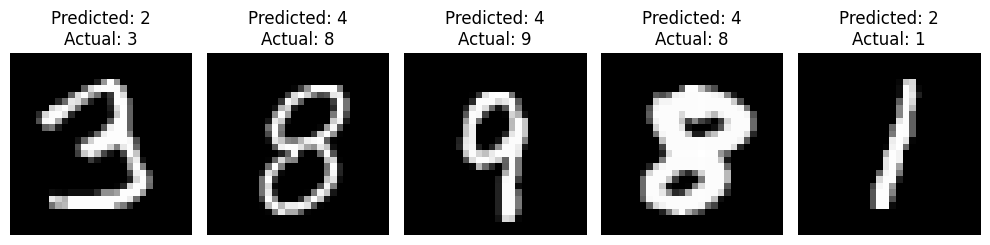

Predicted labels for selected samples: [2 4 4 4 2]


In [46]:
predictions = model.predict(random_samples)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 4))
for i in range(len(random_indices)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(random_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}\nActual: {actual_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Predicted labels for selected samples:", predicted_labels)